Loading: sub-01_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5
Available clips: ['ses-001_task-s01e02a', 'ses-001_task-s01e02b', 'ses-001_task-s01e03a', 'ses-001_task-s01e03b', 'ses-002_task-s01e04a', 'ses-002_task-s01e04b', 'ses-002_task-s01e05a', 'ses-002_task-s01e05b', 'ses-003_task-s01e01a', 'ses-003_task-s01e01b', 'ses-003_task-s01e06a', 'ses-003_task-s01e06b', 'ses-004_task-s01e07a', 'ses-004_task-s01e07b', 'ses-004_task-s01e08a', 'ses-004_task-s01e08b', 'ses-004_task-s01e09a', 'ses-004_task-s01e09b', 'ses-005_task-s01e10a', 'ses-005_task-s01e10b', 'ses-005_task-s01e11a', 'ses-005_task-s01e11b', 'ses-006_task-s01e12a', 'ses-006_task-s01e12b', 'ses-006_task-s01e13a', 'ses-006_task-s01e13b', 'ses-006_task-s01e14a', 'ses-006_task-s01e14b', 'ses-007_task-s01e15a', 'ses-007_task-s01e15b', 'ses-007_task-s01e16a', 'ses-007_task-s01e16b', 'ses-007_task-s01e17a', 'ses-007_task-s01e17b', 'ses-008_task-s01e18a', 'ses-008_task-s01e18b', 'ses-0

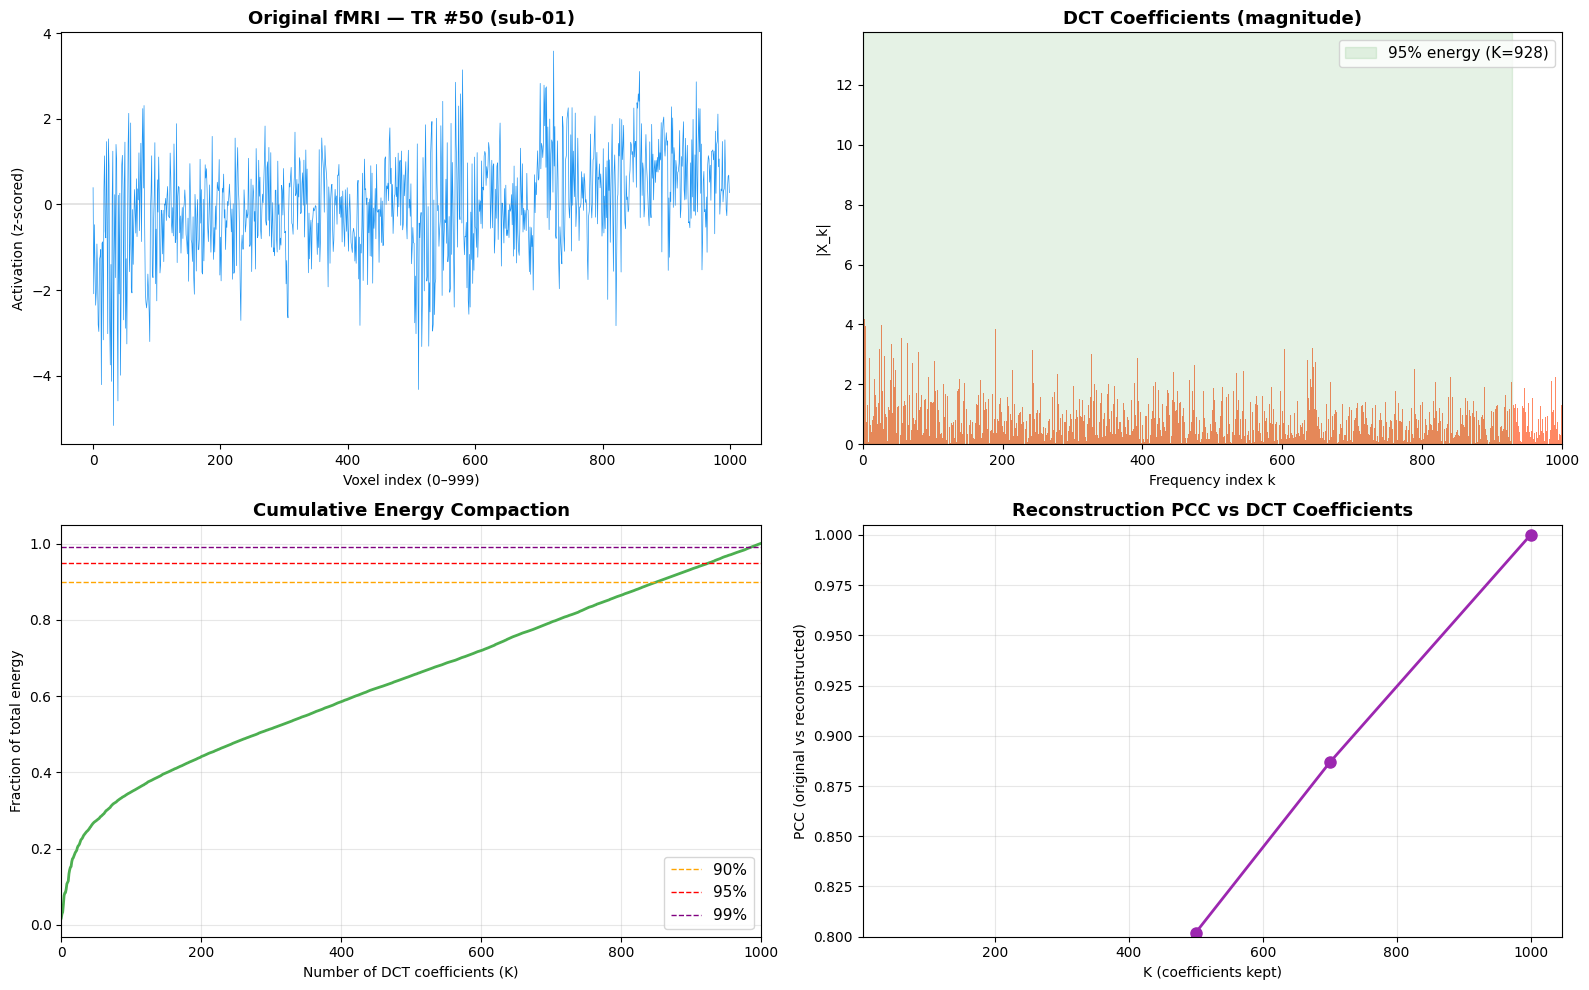

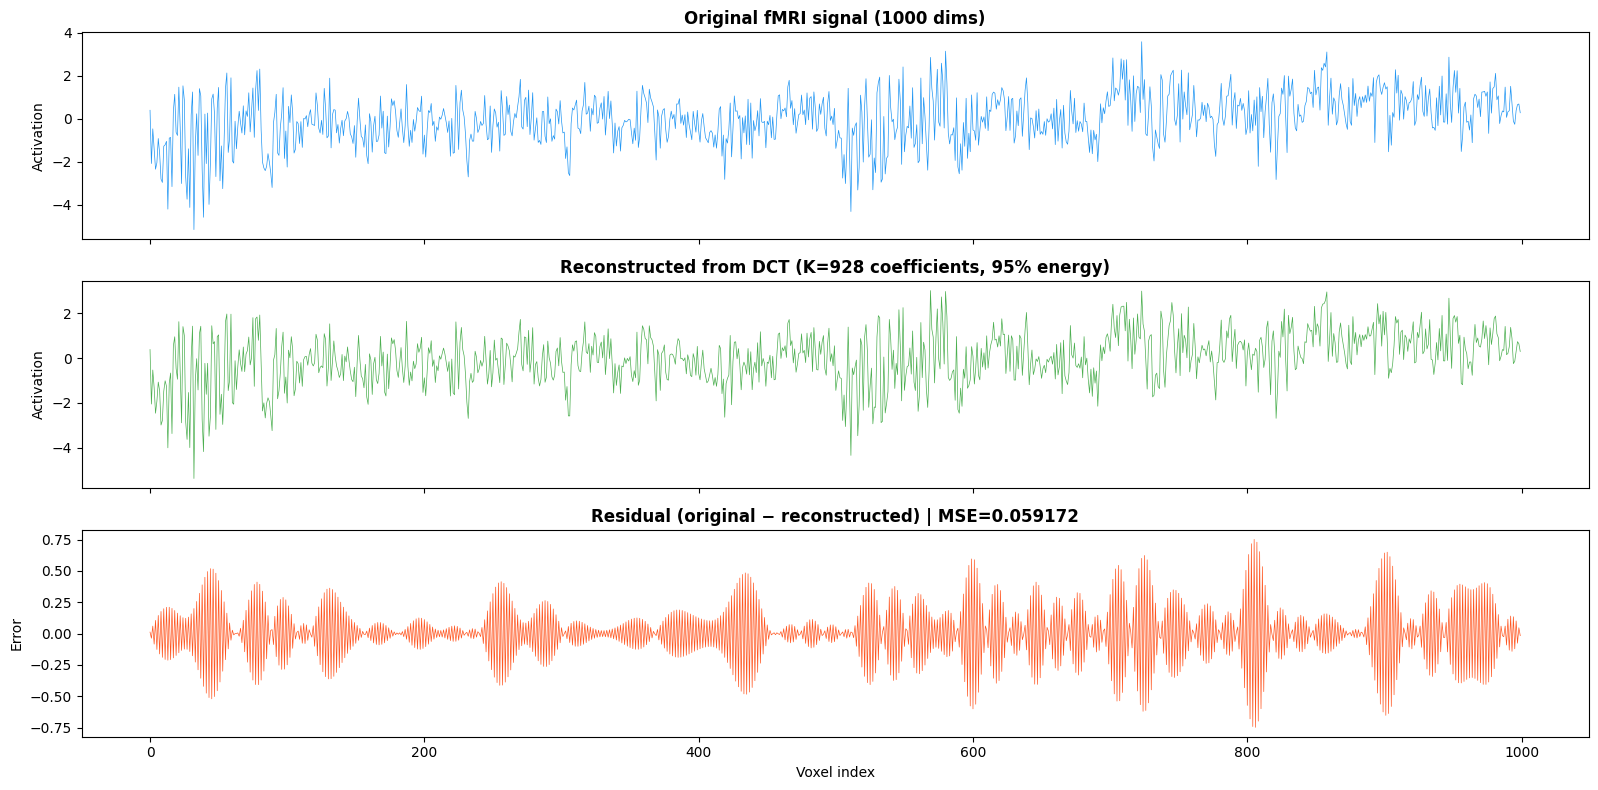


=== CONCLUSION ===
K95 = 928 / 1000 coefficients (92.8%) retain 95% energy
PCC (original vs reconstructed): 0.978797
If K95 << 1000 → DCT is very promising for Spectral Flow Matching
If K95 ≈ 1000  → parcel ordering lacks spatial coherence, DCT won't help


In [2]:
# %% Cell 1: Load fMRI data from H5
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
from pathlib import Path

PROJECT_ROOT = Path("/media/hung/data1/codes/multimodal")
fmri_dir = PROJECT_ROOT / "Data/algonauts_2025.competitors/fmri"
subject = "sub-01"

# Load global stats
stats_dir = fmri_dir / subject / "stats"
global_mean = np.load(stats_dir / "global_mean.npy")
global_std = np.load(stats_dir / "global_std.npy")

# fMRI is stored as H5 files
h5_path = fmri_dir / subject / "func" / (
    f"{subject}_task-friends_space-MNI152NLin2009cAsym_"
    f"atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"
)
print(f"Loading: {h5_path.name}")

with h5py.File(h5_path, "r") as f:
    print(f"Available clips: {list(f.keys())}")
    clip_key = list(f.keys())[0]
    fmri_clip = f[clip_key][:].astype(np.float32)

print(f"Clip '{clip_key}' shape: {fmri_clip.shape}")  # (n_trs, 1000)

# Z-score normalize
fmri_clip = np.nan_to_num(fmri_clip, nan=0.0)
fmri_clip = (fmri_clip - global_mean[None, :]) / global_std[None, :]

n_trs, n_voxels = fmri_clip.shape
print(f"Loaded {n_trs} TRs x {n_voxels} voxels (z-scored)")

# %% Cell 2: Apply DCT and analyze energy compaction
sample_tr = fmri_clip[50]  # single 1000-dim vector

# DCT type-II, orthonormal
sample_dct = dct(sample_tr, type=2, norm='ortho')
clip_dct = dct(fmri_clip, type=2, norm='ortho', axis=-1)  # (n_trs, 1000)

# Average energy per coefficient across all TRs
energy_per_coeff = np.mean(clip_dct ** 2, axis=0)  # (1000,)
cumulative_energy = np.cumsum(energy_per_coeff) / np.sum(energy_per_coeff)

# Find K to retain 90%, 95%, 99% energy
for threshold in [0.90, 0.95, 0.99]:
    K = np.searchsorted(cumulative_energy, threshold) + 1
    print(f"{threshold*100:.0f}% energy retained with K={K}/{n_voxels} coefficients ({K/n_voxels*100:.1f}%)")

# %% Cell 3: 4-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Original fMRI signal (1 TR)
ax = axes[0, 0]
ax.plot(sample_tr, linewidth=0.5, color='#2196F3')
ax.set_title(f'Original fMRI — TR #50 ({subject})', fontsize=13, fontweight='bold')
ax.set_xlabel('Voxel index (0–999)')
ax.set_ylabel('Activation (z-scored)')
ax.axhline(0, color='gray', linewidth=0.3)

# Panel 2: DCT coefficients (1 TR)
ax = axes[0, 1]
ax.bar(range(n_voxels), np.abs(sample_dct), width=1.0, color='#FF5722', alpha=0.7)
ax.set_title('DCT Coefficients (magnitude)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency index k')
ax.set_ylabel('|X_k|')
ax.set_xlim(0, n_voxels)
K95 = np.searchsorted(cumulative_energy, 0.95) + 1
ax.axvspan(0, K95, alpha=0.1, color='green', label=f'95% energy (K={K95})')
ax.legend(fontsize=11)

# Panel 3: Cumulative energy curve
ax = axes[1, 0]
ax.plot(cumulative_energy, linewidth=2, color='#4CAF50')
ax.axhline(0.90, color='orange', linestyle='--', linewidth=1, label='90%')
ax.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95%')
ax.axhline(0.99, color='purple', linestyle='--', linewidth=1, label='99%')
ax.set_title('Cumulative Energy Compaction', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of DCT coefficients (K)')
ax.set_ylabel('Fraction of total energy')
ax.legend(fontsize=11)
ax.set_xlim(0, n_voxels)
ax.grid(True, alpha=0.3)

# Panel 4: Reconstruction PCC vs K
ax = axes[1, 1]
K_values = [50, 100, 200, 300, 500, 700, 1000]
errors = []
for K in K_values:
    truncated = clip_dct.copy()
    truncated[:, K:] = 0
    reconstructed = idct(truncated, type=2, norm='ortho', axis=-1)
    mse = np.mean((fmri_clip - reconstructed) ** 2)
    pcc = np.mean([np.corrcoef(fmri_clip[t], reconstructed[t])[0, 1]
                   for t in range(0, n_trs, max(1, n_trs // 50))])
    errors.append((K, mse, pcc))
    print(f"K={K:4d} | MSE={mse:.6f} | PCC={pcc:.4f}")

Ks, mses, pccs = zip(*errors)
ax.plot(Ks, pccs, 'o-', color='#9C27B0', linewidth=2, markersize=8)
ax.set_title('Reconstruction PCC vs DCT Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('K (coefficients kept)')
ax.set_ylabel('PCC (original vs reconstructed)')
ax.set_ylim(0.8, 1.005)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dct_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# %% Cell 4: Original vs DCT-truncated comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

K_demo = np.searchsorted(cumulative_energy, 0.95) + 1
truncated = sample_dct.copy()
truncated[K_demo:] = 0
reconstructed = idct(truncated, type=2, norm='ortho')

axes[0].plot(sample_tr, linewidth=0.5, color='#2196F3')
axes[0].set_title('Original fMRI signal (1000 dims)', fontweight='bold')
axes[0].set_ylabel('Activation')

axes[1].plot(reconstructed, linewidth=0.5, color='#4CAF50')
axes[1].set_title(f'Reconstructed from DCT (K={K_demo} coefficients, 95% energy)', fontweight='bold')
axes[1].set_ylabel('Activation')

residual = sample_tr - reconstructed
axes[2].plot(residual, linewidth=0.5, color='#FF5722')
axes[2].set_title(f'Residual (original − reconstructed) | MSE={np.mean(residual**2):.6f}', fontweight='bold')
axes[2].set_xlabel('Voxel index')
axes[2].set_ylabel('Error')

plt.tight_layout()
plt.savefig('dct_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== CONCLUSION ===")
print(f"K95 = {K_demo} / {n_voxels} coefficients ({K_demo/n_voxels*100:.1f}%) retain 95% energy")
print(f"PCC (original vs reconstructed): {np.corrcoef(sample_tr, reconstructed)[0,1]:.6f}")
print(f"If K95 << 1000 → DCT is very promising for Spectral Flow Matching")
print(f"If K95 ≈ 1000  → parcel ordering lacks spatial coherence, DCT won't help")


Total data: 9876 TRs x 1000 voxels
Network assignment: 1000 parcels
  [0] Visual         :  150 parcels
  [1] SomMot         :  148 parcels
  [2] DorsAttn       :  132 parcels
  [3] SalVentAttn    :  136 parcels
  [4] Limbic         :   76 parcels
  [5] Cont           :  122 parcels
  [6] Default        :  236 parcels

Computing 1000×1000 correlation matrix...

WITHIN-NETWORK  mean corr: 0.1215 ± 0.1886
BETWEEN-NETWORK mean corr: 0.0066 ± 0.1365
Ratio (within/between):    18.38x

Per-network mean within-correlation:
  Visual         : 0.2021
  SomMot         : 0.1416
  SalVentAttn    : 0.1124
  Default        : 0.1027
  DorsAttn       : 0.1018
  Cont           : 0.1008
  Limbic         : 0.0535


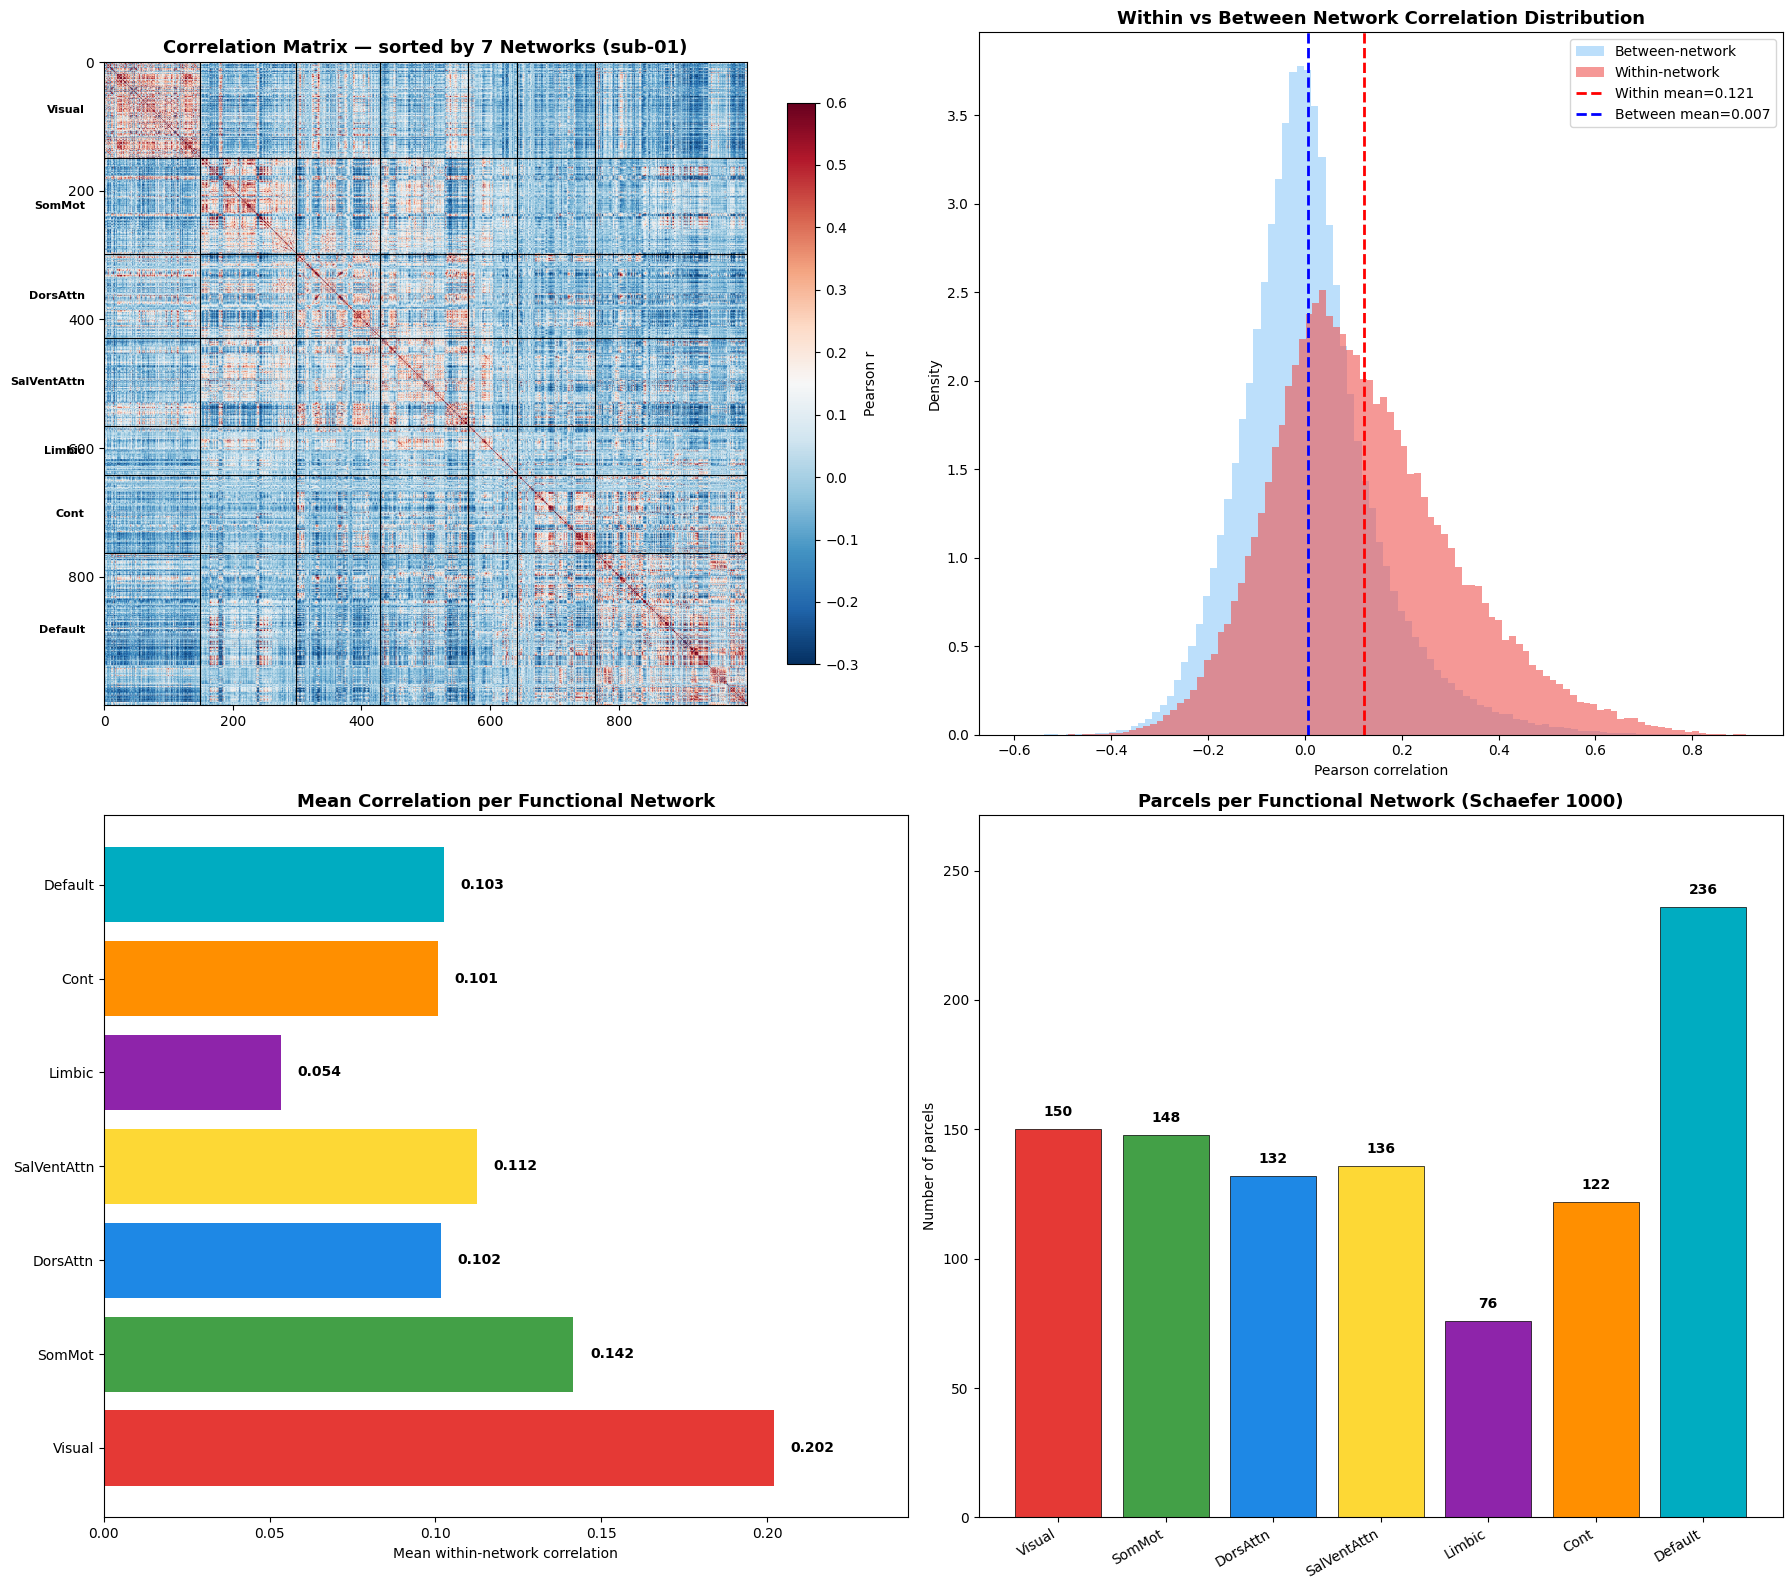


DCT WITHIN EACH NETWORK (energy compaction test)
  Visual          (150 parcels): K90=129 (86%)  K95=140 (93%)
  SomMot          (148 parcels): K90=126 (85%)  K95=137 (93%)
  DorsAttn        (132 parcels): K90=113 (86%)  K95=122 (92%)
  SalVentAttn     (136 parcels): K90=118 (87%)  K95=127 (93%)
  Limbic          ( 76 parcels): K90= 67 (88%)  K95= 72 (95%)
  Cont            (122 parcels): K90=104 (85%)  K95=113 (93%)
  Default         (236 parcels): K90=201 (85%)  K95=220 (93%)


In [3]:
# %% Cell 5: Functional Network Analysis — Verify Proposal 1
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# ── 1. Load fMRI data (multiple clips for robust statistics) ──
PROJECT_ROOT = Path("/media/hung/data1/codes/multimodal")
fmri_dir = PROJECT_ROOT / "Data/algonauts_2025.competitors/fmri"
subject = "sub-01"

stats_dir = fmri_dir / subject / "stats"
global_mean = np.load(stats_dir / "global_mean.npy")
global_std = np.load(stats_dir / "global_std.npy")

h5_path = fmri_dir / subject / "func" / (
    f"{subject}_task-friends_space-MNI152NLin2009cAsym_"
    f"atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"
)

# Load multiple clips for better correlation estimate
all_data = []
with h5py.File(h5_path, "r") as f:
    keys = list(f.keys())
    for k in keys[:20]:  # first 20 clips (~10,000 TRs)
        raw = f[k][:].astype(np.float32)
        raw = np.nan_to_num(raw, nan=0.0)
        raw = (raw - global_mean[None, :]) / global_std[None, :]
        all_data.append(raw)

fmri_all = np.concatenate(all_data, axis=0)
print(f"Total data: {fmri_all.shape[0]} TRs x {fmri_all.shape[1]} voxels")

# ── 2. Define Schaefer 1000 × 7-Network mapping ──
# Schaefer atlas: parcels are ordered by network, each hemisphere has
# 500 parcels. Within each hemisphere, parcels are grouped:
#   Visual → SomMot → DorsAttn → SalVentAttn → Limbic → Cont → Default
# The exact split for 1000Par7Net (Schaefer 2018):
# Reference: https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal

# Standard Schaefer 1000-parcel 7-network assignment (per hemisphere: 500)
# These counts are from the official Schaefer atlas labels
network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
# Per hemisphere parcel counts for 1000Par7Net
counts_per_hemi = [75, 74, 66, 68, 38, 61, 118]  # sum = 500

# Build parcel-to-network mapping (LH first, then RH — same order)
parcel_to_network = []
for hemi in range(2):
    for net_idx, count in enumerate(counts_per_hemi):
        parcel_to_network.extend([net_idx] * count)

parcel_to_network = np.array(parcel_to_network)
print(f"Network assignment: {len(parcel_to_network)} parcels")
for i, name in enumerate(network_names):
    n = (parcel_to_network == i).sum()
    print(f"  [{i}] {name:15s}: {n:4d} parcels")

# If this doesn't match, fall back to data-driven clustering
if len(parcel_to_network) != fmri_all.shape[1]:
    print(f"\n⚠ Mismatch: expected {fmri_all.shape[1]}, got {len(parcel_to_network)}")
    print("Falling back to correlation-based clustering...")
    from scipy.cluster.hierarchy import fcluster, linkage
    corr = np.corrcoef(fmri_all.T)
    Z = linkage(1 - corr, method='ward')
    parcel_to_network = fcluster(Z, t=7, criterion='maxclust') - 1

# ── 3. Compute correlation matrix (voxel × voxel) ──
print("\nComputing 1000×1000 correlation matrix...")
corr_matrix = np.corrcoef(fmri_all.T)  # (1000, 1000)

# ── 4. Sort parcels by network for block visualization ──
sort_idx = np.argsort(parcel_to_network)
corr_sorted = corr_matrix[np.ix_(sort_idx, sort_idx)]
networks_sorted = parcel_to_network[sort_idx]

# ── 5. Compute within-network vs between-network statistics ──
within_corrs = []
between_corrs = []
per_network_corr = {}

for i in range(7):
    mask_i = parcel_to_network == i
    idx_i = np.where(mask_i)[0]

    # Within-network: upper triangle of sub-matrix
    sub = corr_matrix[np.ix_(idx_i, idx_i)]
    triu = sub[np.triu_indices(len(idx_i), k=1)]
    within_corrs.extend(triu)
    per_network_corr[network_names[i]] = np.mean(triu)

    # Between-network: all pairs with other networks
    for j in range(i + 1, 7):
        mask_j = parcel_to_network == j
        idx_j = np.where(mask_j)[0]
        cross = corr_matrix[np.ix_(idx_i, idx_j)].ravel()
        between_corrs.extend(cross)

within_corrs = np.array(within_corrs)
between_corrs = np.array(between_corrs)

print(f"\n{'='*50}")
print(f"WITHIN-NETWORK  mean corr: {within_corrs.mean():.4f} ± {within_corrs.std():.4f}")
print(f"BETWEEN-NETWORK mean corr: {between_corrs.mean():.4f} ± {between_corrs.std():.4f}")
print(f"Ratio (within/between):    {within_corrs.mean() / max(between_corrs.mean(), 1e-6):.2f}x")
print(f"{'='*50}")
print(f"\nPer-network mean within-correlation:")
for name, corr in sorted(per_network_corr.items(), key=lambda x: -x[1]):
    print(f"  {name:15s}: {corr:.4f}")

# ── 6. Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Panel 1: Full correlation matrix (sorted by network)
ax = axes[0, 0]
im = ax.imshow(corr_sorted, cmap='RdBu_r', vmin=-0.3, vmax=0.6, aspect='equal')
# Draw network boundaries
boundaries = [0]
for c in counts_per_hemi * 2:  # LH + RH
    boundaries.append(boundaries[-1] + c)
# Merge LH+RH for same network
net_bounds = [0]
for i in range(7):
    net_bounds.append(net_bounds[-1] + 2 * counts_per_hemi[i])
for b in net_bounds[1:-1]:
    ax.axhline(b - 0.5, color='black', linewidth=0.8)
    ax.axvline(b - 0.5, color='black', linewidth=0.8)
# Labels
for i, name in enumerate(network_names):
    mid = (net_bounds[i] + net_bounds[i + 1]) / 2
    ax.text(-30, mid, name, ha='right', va='center', fontsize=8, fontweight='bold')
ax.set_title(f'Correlation Matrix — sorted by 7 Networks ({subject})',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')

# Panel 2: Within vs Between distribution
ax = axes[0, 1]
ax.hist(between_corrs, bins=100, alpha=0.6, color='#90CAF9', label='Between-network', density=True)
ax.hist(within_corrs, bins=100, alpha=0.6, color='#EF5350', label='Within-network', density=True)
ax.axvline(within_corrs.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Within mean={within_corrs.mean():.3f}')
ax.axvline(between_corrs.mean(), color='blue', linestyle='--', linewidth=2,
           label=f'Between mean={between_corrs.mean():.3f}')
ax.set_title('Within vs Between Network Correlation Distribution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson correlation')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

# Panel 3: Per-network mean correlation (bar chart)
ax = axes[1, 0]
names = list(per_network_corr.keys())
vals = list(per_network_corr.values())
colors = ['#E53935', '#43A047', '#1E88E5', '#FDD835', '#8E24AA', '#FF8F00', '#00ACC1']
bars = ax.barh(names, vals, color=colors[:len(names)])
ax.set_xlabel('Mean within-network correlation')
ax.set_title('Mean Correlation per Functional Network', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(vals) * 1.2)
for bar, val in zip(bars, vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontweight='bold')

# Panel 4: Network size distribution
ax = axes[1, 1]
sizes = [2 * c for c in counts_per_hemi]  # LH + RH
ax.bar(network_names, sizes, color=colors[:7], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Number of parcels')
ax.set_title('Parcels per Functional Network (Schaefer 1000)', fontsize=13, fontweight='bold')
for i, s in enumerate(sizes):
    ax.text(i, s + 5, str(s), ha='center', fontweight='bold')
ax.set_ylim(0, max(sizes) * 1.15)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('functional_network_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. DCT within each network (bonus: does per-network DCT work?) ──
print(f"\n{'='*50}")
print("DCT WITHIN EACH NETWORK (energy compaction test)")
print(f"{'='*50}")
from scipy.fft import dct

for i, name in enumerate(network_names):
    mask = parcel_to_network == i
    n_parcels = mask.sum()
    net_data = fmri_all[:, mask]  # (TRs, n_parcels)

    net_dct = dct(net_data, type=2, norm='ortho', axis=-1)
    energy = np.mean(net_dct ** 2, axis=0)
    cum_energy = np.cumsum(energy) / np.sum(energy)

    K90 = np.searchsorted(cum_energy, 0.90) + 1
    K95 = np.searchsorted(cum_energy, 0.95) + 1

    print(f"  {name:15s} ({n_parcels:3d} parcels): "
          f"K90={K90:3d} ({K90/n_parcels*100:.0f}%)  "
          f"K95={K95:3d} ({K95/n_parcels*100:.0f}%)")
